Dataset Shape: (150, 4)

Features:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target Classes:
['setosa' 'versicolor' 'virginica']

Complete Dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Species              0
dtype: int64

Class Distribution:
Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


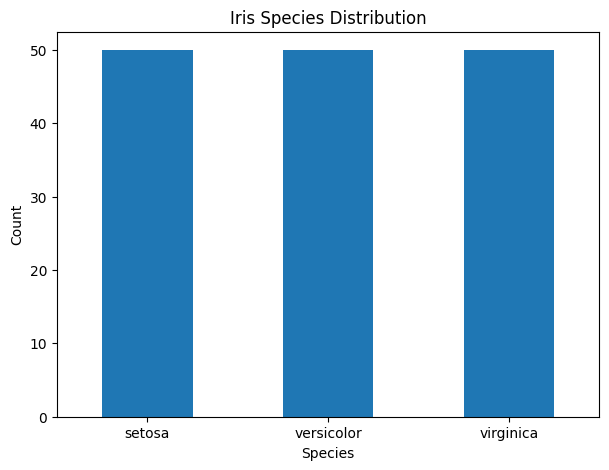

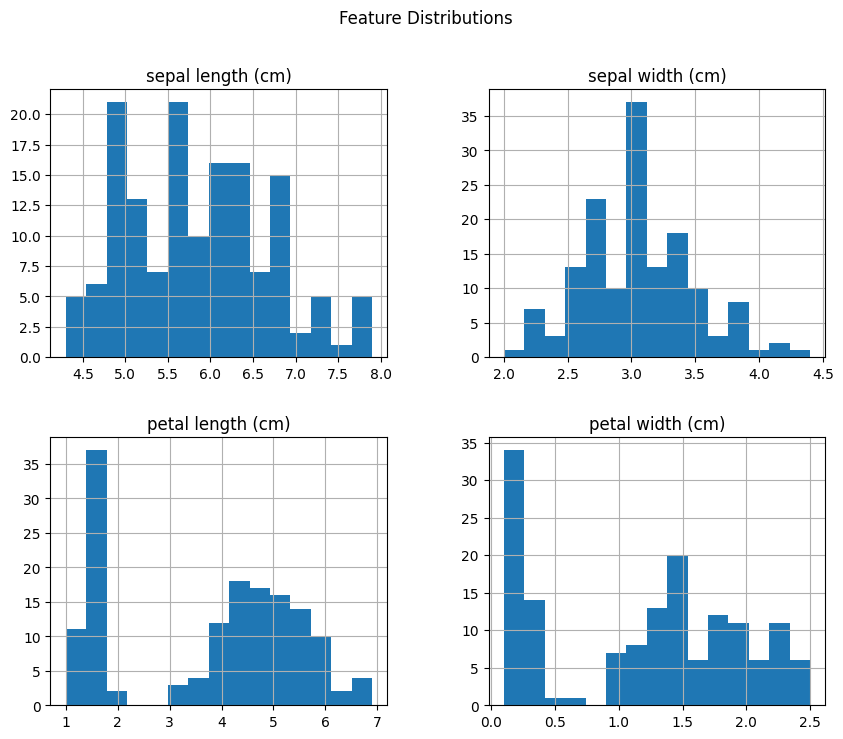

X Shape: (150, 4)
Y Shape: (150,)

Training Data: (120, 4)
Testing Data: (30, 4)
Logistic Regression
Accuracy: 0.9333
Decision Tree
Accuracy: 0.9333
Random Forest
Accuracy: 0.9
KNN
Accuracy: 0.9333

MODEL COMPARISON


,Model,Accuracy
0,Logistic Regression,0.933333
1,Decision Tree,0.933333
3,KNN,0.933333
2,Random Forest,0.900000


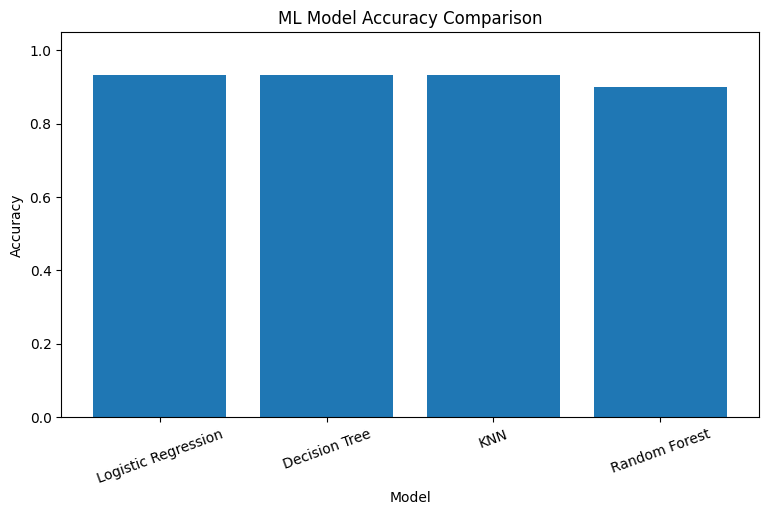

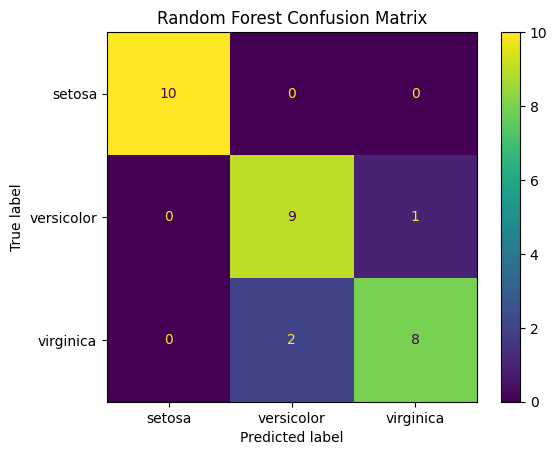

Random Forest Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30


New Flower Measurements:
[[5.1 3.5 1.4 0.2]]

Predicted Species:
setosa

FINAL RESULT
Best performing model: Logistic Regression
Accuracy: 93.33 %


In [2]:
# ============================================================
# SIMPLE MACHINE LEARNING ASSIGNMENT
# IRIS FLOWER CLASSIFICATION
# ============================================================

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ============================================================
# 2. LOAD DATASET
# ============================================================

iris = load_iris()

X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

y = pd.Series(
    iris.target,
    name="Species"
)

print("Dataset Shape:", X.shape)
print("\nFeatures:")
print(X.head())

print("\nTarget Classes:")
print(iris.target_names)

# ============================================================
# 3. CREATE COMPLETE DATAFRAME
# ============================================================

df = X.copy()
df["Species"] = y

# Convert numeric target into species names
df["Species"] = df["Species"].map(
    dict(enumerate(iris.target_names))
)

print("\nComplete Dataset:")
display(df.head())

# ============================================================
# 4. BASIC DATA UNDERSTANDING
# ============================================================

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
display(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df["Species"].value_counts())

# ============================================================
# 5. EDA - TARGET DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 5))

df["Species"].value_counts().plot(kind="bar")

plt.title("Iris Species Distribution")
plt.xlabel("Species")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# ============================================================
# 6. EDA - FEATURE DISTRIBUTION
# ============================================================

df.iloc[:, :4].hist(
    figsize=(10, 8),
    bins=15
)

plt.suptitle("Feature Distributions")
plt.show()

# ============================================================
# 7. PREPARE X AND Y
# ============================================================

X = iris.data
y = iris.target

print("X Shape:", X.shape)
print("Y Shape:", y.shape)

# ============================================================
# 8. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)

# ============================================================
# 9. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================
# 10. DEFINE ML MODELS
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# ============================================================
# 11. TRAIN AND COMPARE MODELS
# ============================================================

results = {}

for name, model in models.items():

    # KNN and Logistic Regression use scaled data
    if name in ["Logistic Regression", "KNN"]:
        model.fit(X_train_scaled, y_train)
        predictions = model.predict(X_test_scaled)

    else:
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    results[name] = accuracy

    print("=" * 60)
    print(name)
    print("Accuracy:", round(accuracy, 4))

# ============================================================
# 12. MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(
    list(results.items()),
    columns=["Model", "Accuracy"]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\nMODEL COMPARISON")
display(results_df)

# ============================================================
# 13. ACCURACY VISUALIZATION
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.title("ML Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1.05)
plt.xticks(rotation=20)

plt.show()

# ============================================================
# 14. CONFUSION MATRIX - RANDOM FOREST
# ============================================================

rf_model = models["Random Forest"]

rf_predictions = rf_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    rf_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

# ============================================================
# 15. CLASSIFICATION REPORT
# ============================================================

print("Random Forest Classification Report")

print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=iris.target_names
    )
)

# ============================================================
# 16. TEST WITH A NEW FLOWER
# ============================================================

new_flower = np.array([
    [5.1, 3.5, 1.4, 0.2]
])

prediction = rf_model.predict(new_flower)

print("\nNew Flower Measurements:")
print(new_flower)

print("\nPredicted Species:")
print(iris.target_names[prediction[0]])

# ============================================================
# 17. FINAL CONCLUSION
# ============================================================

best_model = results_df.iloc[0]["Model"]
best_accuracy = results_df.iloc[0]["Accuracy"]

print("\n" + "=" * 60)
print("FINAL RESULT")
print("=" * 60)

print("Best performing model:", best_model)
print("Accuracy:", round(best_accuracy * 100, 2), "%")

Dataset Shape: (150, 4)

Features:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target Classes:
['setosa' 'versicolor' 'virginica']

Complete Dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Species              0
dtype: int64

Class Distribution:
Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


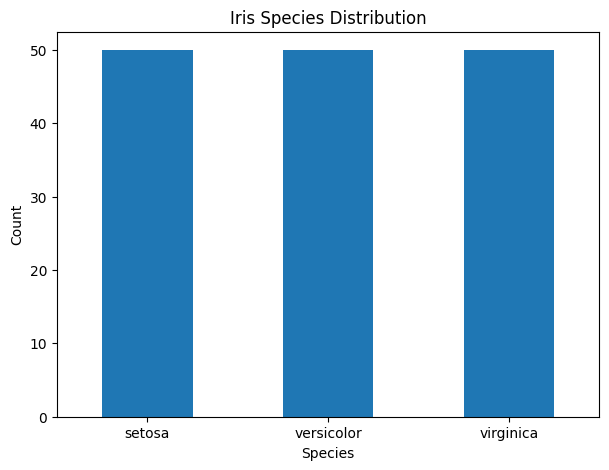

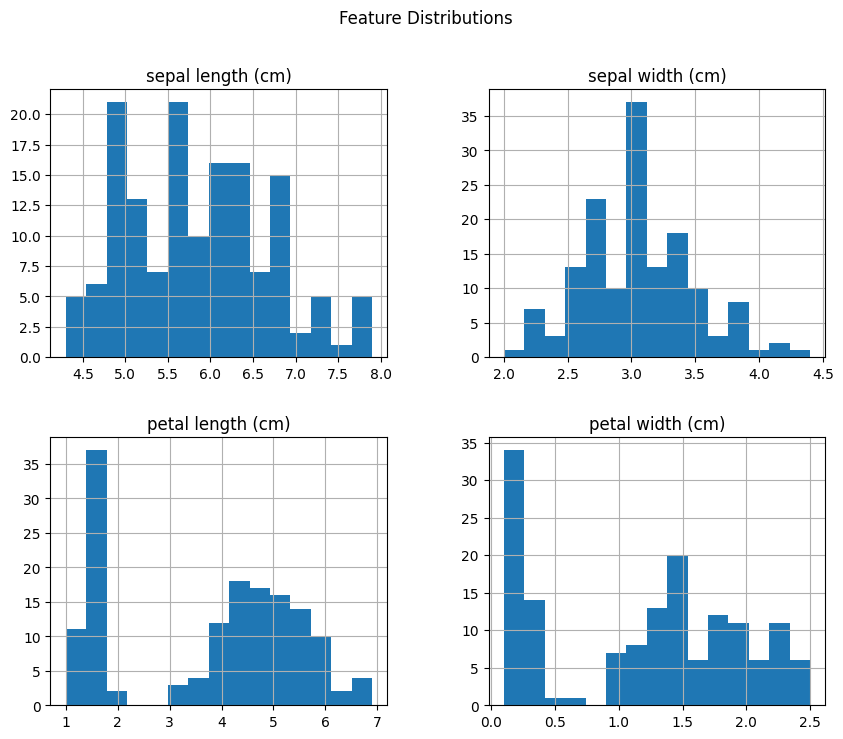

X Shape: (150, 4)
Y Shape: (150,)

Training Data: (120, 4)
Testing Data: (30, 4)
Logistic Regression
Accuracy: 0.9333
Decision Tree
Accuracy: 0.9333
Random Forest
Accuracy: 0.9
KNN
Accuracy: 0.9333

MODEL COMPARISON


,Model,Accuracy
0,Logistic Regression,0.933333
1,Decision Tree,0.933333
3,KNN,0.933333
2,Random Forest,0.900000


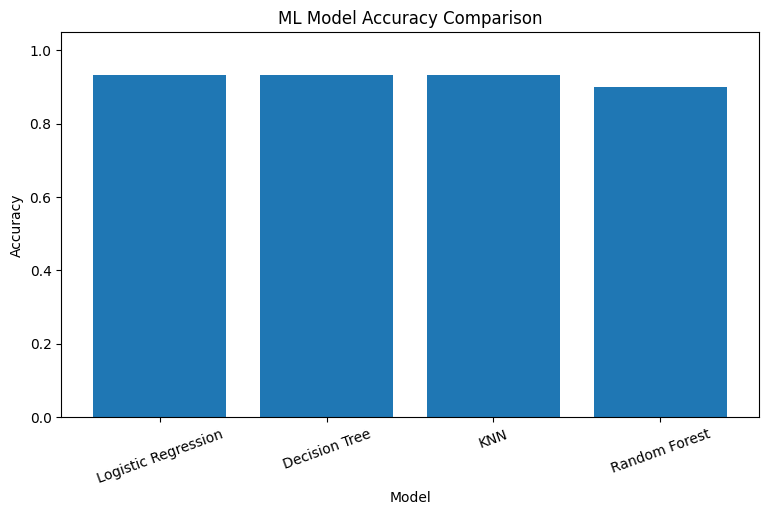

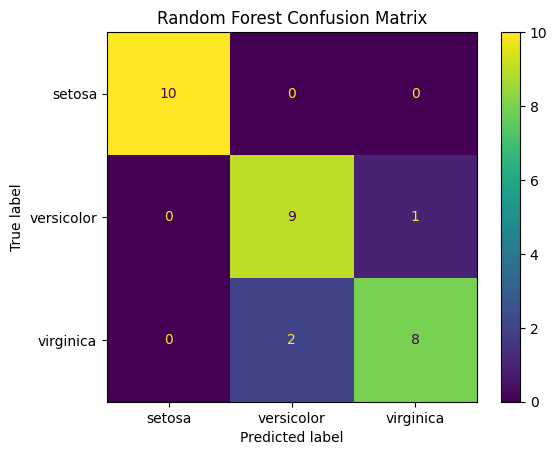

Random Forest Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30


New Flower Measurements:
[[5.1 3.5 1.4 0.2]]

Predicted Species:
setosa

FINAL RESULT
Best performing model: Logistic Regression
Accuracy: 93.33 %


In [3]:
# ============================================================
# SIMPLE MACHINE LEARNING ASSIGNMENT
# IRIS FLOWER CLASSIFICATION
# ============================================================

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ============================================================
# 2. LOAD DATASET
# ============================================================

iris = load_iris()

X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

y = pd.Series(
    iris.target,
    name="Species"
)

print("Dataset Shape:", X.shape)
print("\nFeatures:")
print(X.head())

print("\nTarget Classes:")
print(iris.target_names)

# ============================================================
# 3. CREATE COMPLETE DATAFRAME
# ============================================================

df = X.copy()
df["Species"] = y

# Convert numeric target into species names
df["Species"] = df["Species"].map(
    dict(enumerate(iris.target_names))
)

print("\nComplete Dataset:")
display(df.head())

# ============================================================
# 4. BASIC DATA UNDERSTANDING
# ============================================================

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
display(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df["Species"].value_counts())

# ============================================================
# 5. EDA - TARGET DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 5))

df["Species"].value_counts().plot(kind="bar")

plt.title("Iris Species Distribution")
plt.xlabel("Species")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# ============================================================
# 6. EDA - FEATURE DISTRIBUTION
# ============================================================

df.iloc[:, :4].hist(
    figsize=(10, 8),
    bins=15
)

plt.suptitle("Feature Distributions")
plt.show()

# ============================================================
# 7. PREPARE X AND Y
# ============================================================

X = iris.data
y = iris.target

print("X Shape:", X.shape)
print("Y Shape:", y.shape)

# ============================================================
# 8. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)

# ============================================================
# 9. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================
# 10. DEFINE ML MODELS
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# ============================================================
# 11. TRAIN AND COMPARE MODELS
# ============================================================

results = {}

for name, model in models.items():

    # KNN and Logistic Regression use scaled data
    if name in ["Logistic Regression", "KNN"]:
        model.fit(X_train_scaled, y_train)
        predictions = model.predict(X_test_scaled)

    else:
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    results[name] = accuracy

    print("=" * 60)
    print(name)
    print("Accuracy:", round(accuracy, 4))

# ============================================================
# 12. MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(
    list(results.items()),
    columns=["Model", "Accuracy"]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\nMODEL COMPARISON")
display(results_df)

# ============================================================
# 13. ACCURACY VISUALIZATION
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.title("ML Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1.05)
plt.xticks(rotation=20)

plt.show()

# ============================================================
# 14. CONFUSION MATRIX - RANDOM FOREST
# ============================================================

rf_model = models["Random Forest"]

rf_predictions = rf_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    rf_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

# ============================================================
# 15. CLASSIFICATION REPORT
# ============================================================

print("Random Forest Classification Report")

print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=iris.target_names
    )
)

# ============================================================
# 16. TEST WITH A NEW FLOWER
# ============================================================

new_flower = np.array([
    [5.1, 3.5, 1.4, 0.2]
])

prediction = rf_model.predict(new_flower)

print("\nNew Flower Measurements:")
print(new_flower)

print("\nPredicted Species:")
print(iris.target_names[prediction[0]])

# ============================================================
# 17. FINAL CONCLUSION
# ============================================================

best_model = results_df.iloc[0]["Model"]
best_accuracy = results_df.iloc[0]["Accuracy"]

print("\n" + "=" * 60)
print("FINAL RESULT")
print("=" * 60)

print("Best performing model:", best_model)
print("Accuracy:", round(best_accuracy * 100, 2), "%")

## Conclusion

Based on the analysis, the best performing models for the Iris flower classification are **Logistic Regression**, **Decision Tree**, and **KNN**, all achieving an accuracy of **93.33%**.